In [39]:
from pathlib import Path
import multiprocessing as mp

import pandas as pd

In [40]:
from results.repetition import RepetitionResults
from results.results import Results

## Configuration


### Path Configuration


In [41]:
RES_PARENT_FOLDER = Path("../../results").resolve()
RES_PARENT_FOLDER.mkdir(exist_ok=True)
BATCH_RES = RES_PARENT_FOLDER / "batch_20260204_17-30-33"
BATCH_RES = RES_PARENT_FOLDER / "batch_20260206_21-45-57"


if not BATCH_RES.exists():
    raise FileNotFoundError(
        f"Results folder not found: {BATCH_RES}"
    )

In [42]:
results = Results.from_folder(BATCH_RES)

Reading topology results from folder: linear_20N
Reading topology results from folder: ring_20N
Reading topology results from folder: grid_20N
Reading topology results from folder: random_20N
Reading topology results from folder: star_20N


In [43]:
PROCESSED_RES_FOLDER = RES_PARENT_FOLDER / "processed_results"
PROCESSED_RES_FOLDER.mkdir(exist_ok=True)
PROCESSED_RES_BATCH = PROCESSED_RES_FOLDER / BATCH_RES.name
PROCESSED_RES_BATCH.mkdir(exist_ok=True)
PROCESSED_RES_FOLDER

PosixPath('/home/simone/uni/spe/SPE-project/results/processed_results')

In [44]:
COMPUTE_HOP_STRETCH = False

In [45]:
if COMPUTE_HOP_STRETCH:

    HS_FOLDER = PROCESSED_RES_BATCH / "hop_stretch"
    HS_FOLDER.mkdir(exist_ok=True)


    def compute_repetition(repetition: RepetitionResults) -> pd.DataFrame:
        try:
            repetition.compute_hop_stretch()
            repetition.hop_stretch_df["id"] = repetition.id
            return repetition.hop_stretch_df
        except ValueError as e:
            if repetition.neighbor_df is None or repetition.positions_df is None:
                return pd.DataFrame(
                    {
                        "id": [repetition.id],
                    }
                )
            else:
                raise e


    worker_count = mp.cpu_count()

    ctx = mp.get_context("fork")

    for topology in results.topologies:
        print(f"Topology: {topology.topology_type}")

        HS_TOPOLOGY_FOLDER = HS_FOLDER / topology.topology_type
        HS_TOPOLOGY_FOLDER.mkdir(exist_ok=True)

        for channel in topology.channels:

            print(f"  Channel: {channel.channel_type}")

            HS_CHANNEL_FOLDER = HS_TOPOLOGY_FOLDER / channel.channel_type
            HS_CHANNEL_FOLDER.mkdir(exist_ok=True)

            with ctx.Pool(worker_count) as pool:
                try:
                    hs = pool.map(
                        compute_repetition,
                        channel.repetitions,
                        chunksize=max(1, len(channel.repetitions) // (mp.cpu_count() * 4)),
                    )
                except Exception as e:
                    print(
                        f"Error computing hop stretch for [{topology.topology_type}/{channel.channel_type}]: {e}"
                    )
                    pool.terminate()
                    pool.join()

            hs_df = pd.concat(hs, ignore_index=True)
            hs_df.to_csv(HS_CHANNEL_FOLDER / "hop_stretch.csv", index=False)

## Visualize the Varios Topologies

In [56]:
from metrics.hop_stretch import build_connectivity_graph, build_tree_topology, get_positions_nx

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [70]:
np.random.seed(40)

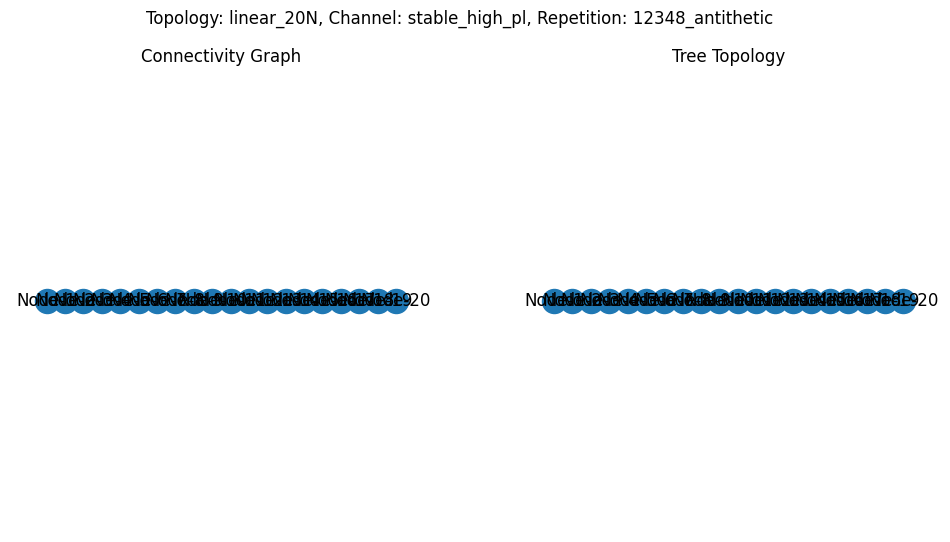

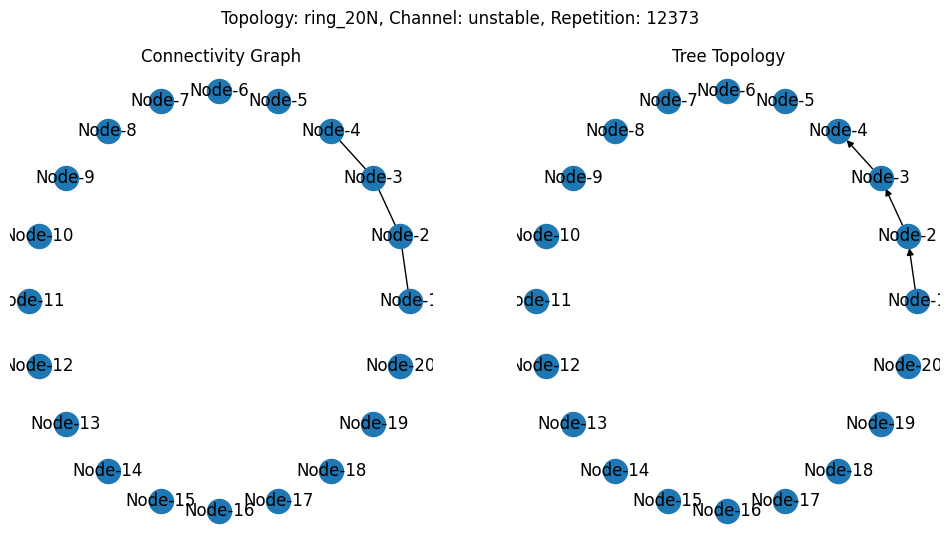

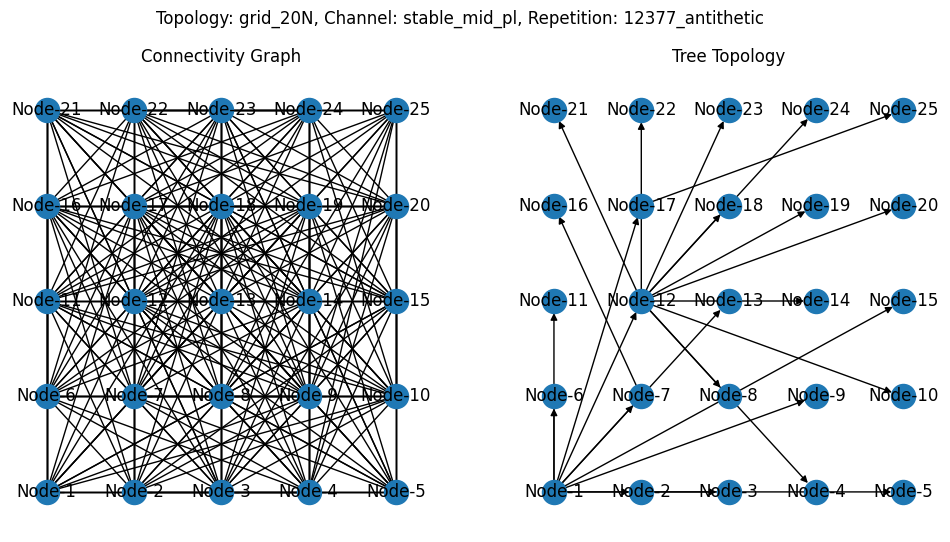

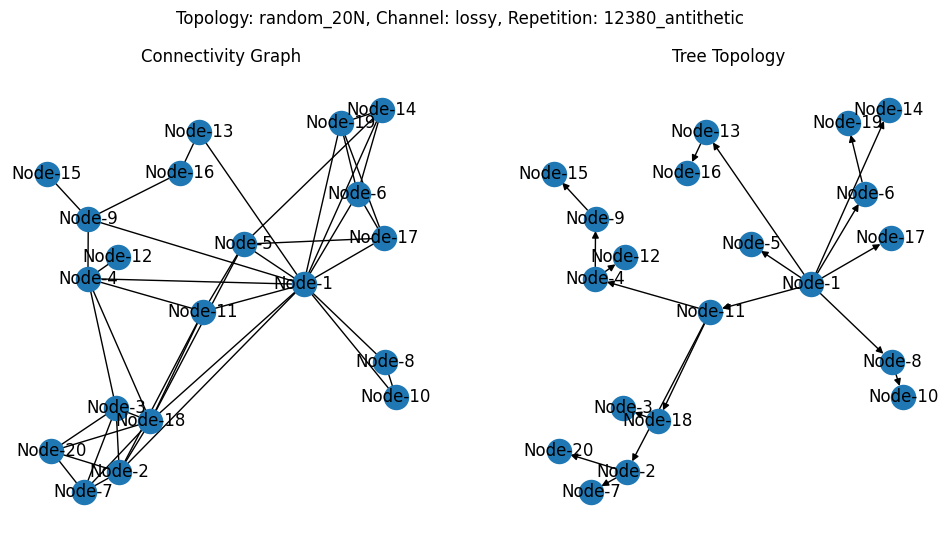

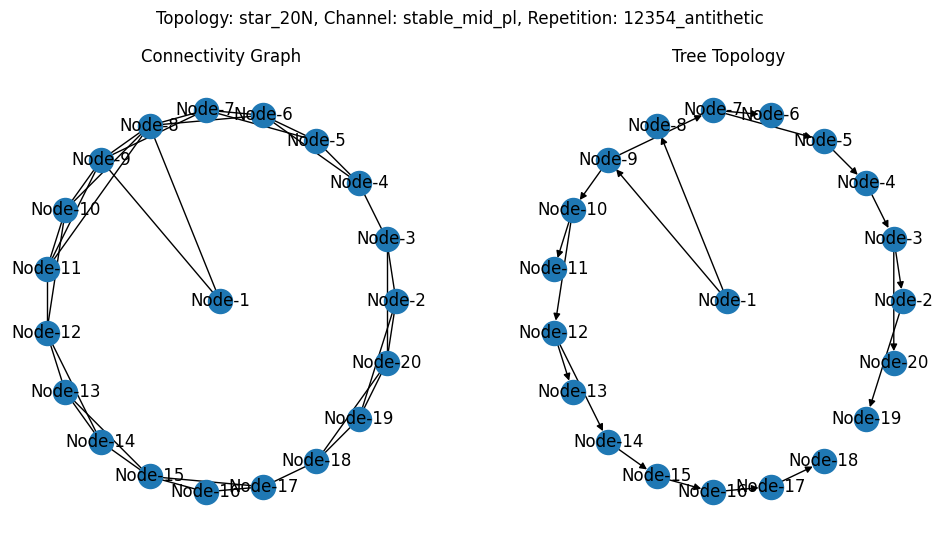

In [71]:
for topology in results.topologies:
    random_channel = np.random.choice(topology.channels)
    rep = np.random.choice(random_channel.repetitions)

    g = build_connectivity_graph(rep, 200)
    t = build_tree_topology(rep, 200)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    nx.draw(g, get_positions_nx(rep), ax=axs[0], with_labels=True)

    nx.draw(t, get_positions_nx(rep), ax=axs[1], with_labels=True)

    plt.suptitle(f"Topology: {topology.topology_type}, Channel: {random_channel.channel_type}, Repetition: {rep.id}")
    axs[0].set_title("Connectivity Graph")
    axs[1].set_title("Tree Topology")

    plt.show()

### Plot the Connectivity Graph